# NYC CBD Bus-Speed Synthetic Control with NTD Donor Agencies

This notebook builds a synthetic-control robustness exercise for the Manhattan congestion-pricing bus-speed project.

The treated unit is the **NYC CBD-exposed route network**, using the original GeoJSON treatment definition:

`cbd_route = True` if any retained route shape intersects the CBD geofence.

The donor pool comes from the NTD monthly service workbook. Donor outcomes are agency-level fixed-route bus speeds:

`average_speed = vehicle revenue miles / vehicle revenue hours`

This is a robustness design, not a replacement for the route-level NYC DiD. The working assumption is that, because the CBD is spatially small and traffic conditions are shared across exposed routes, the aggregate CBD-route network speed is a meaningful treated network series. NTD donor agencies provide broad external transit-network counterfactuals.

Execution note: run this notebook with the project `.venv` Python environment. It uses `openpyxl`, `scipy`, `pandas`, `numpy`, and `statsmodels` from the venv.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_NTD = ROOT / "data" / "raw" / "NTD" / "May 2026 Complete Monthly Ridership (with adjustments and estimates)_260701.xlsx"
NYC_PANEL = ROOT / "data" / "processed" / "nyc_did_panel_geojson_intersection.csv"
PROCESSED = ROOT / "data" / "processed"
TABLES = ROOT / "outputs" / "tables"
FIGURES = ROOT / "outputs" / "figures"

POLICY_MONTH = pd.Timestamp("2025-01-01")
ANALYSIS_START = pd.Timestamp("2023-08-01")
ANALYSIS_END = pd.Timestamp("2026-05-01")

FIXED_ROUTE_BUS_MODES = ["MB", "RB", "TB"]
MAX_DONORS = 60

PROCESSED.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)

## Step 1. Build the Treated NYC CBD Network Series

The NYC panel is already route/month/period/day-type level. For synthetic control, the treated series aggregates all CBD-treated weekday rows into a monthly network speed:

`total mileage / total operating time`

This uses the original treatment definition already stored in the main panel.

In [14]:
def clean_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(",", "", regex=False), errors="coerce")

nyc = pd.read_csv(NYC_PANEL)
nyc["month"] = pd.to_datetime(nyc["month"])
nyc["total_mileage"] = clean_numeric(nyc["total_mileage"])
nyc["total_operating_time"] = clean_numeric(nyc["total_operating_time"])

nyc_treated = nyc[
    nyc["month"].between(ANALYSIS_START, ANALYSIS_END)
    & nyc["day_type"].astype(str).eq("1")
    & nyc["cbd_route"].astype(bool)
].copy()

nyc_network = (
    nyc_treated.groupby("month", as_index=False)
    .agg(
        total_mileage=("total_mileage", "sum"),
        total_operating_time=("total_operating_time", "sum"),
        route_count=("route_id", "nunique"),
        rows=("route_id", "size"),
    )
)
nyc_network["average_speed"] = nyc_network["total_mileage"] / nyc_network["total_operating_time"]
nyc_network["unit_id"] = "NYC_CBD_ROUTES"
nyc_network["unit_name"] = "NYC CBD-treated route network"
nyc_network["post"] = nyc_network["month"].ge(POLICY_MONTH)
nyc_network.head()

,month,total_mileage,total_operating_time,route_count,rows,average_speed,unit_id,unit_name,post
0,2023-08-01,1.343134e+06,172707.648181,84,167,7.776923,NYC_CBD_ROUTES,NYC CBD-treated route network,False
1,2023-09-01,1.013433e+06,138904.502480,84,167,7.295899,NYC_CBD_ROUTES,NYC CBD-treated route network,False
2,2023-10-01,1.236158e+06,167663.246201,84,166,7.372861,NYC_CBD_ROUTES,NYC CBD-treated route network,False
3,2023-11-01,1.156121e+06,156426.897018,84,168,7.390809,NYC_CBD_ROUTES,NYC CBD-treated route network,False
4,2023-12-01,1.058302e+06,141999.195750,84,167,7.452874,NYC_CBD_ROUTES,NYC CBD-treated route network,False


In [15]:
nyc_network.agg(
    months=("month", "nunique"),
    mean_speed=("average_speed", "mean"),
    min_speed=("average_speed", "min"),
    max_speed=("average_speed", "max"),
    mean_routes=("route_count", "mean"),
)

,month,average_speed,route_count
months,34.0,NaN,NaN
mean_speed,NaN,7.590839,NaN
min_speed,NaN,7.295899,NaN
max_speed,NaN,7.923622,NaN
mean_routes,NaN,NaN,84.117647


## Step 2. Build NTD Agency-Level Bus-Speed Donors

The NTD workbook stores monthly measures in wide format. This section reads `VRM` and `VRH`, keeps fixed-route bus modes, aggregates across type of service for each agency/month, and computes:

`average_speed = bus_vrm / bus_vrh`

Modes retained:

- `MB`: motor bus
- `RB`: bus rapid transit
- `TB`: trolleybus

The primary donor definition excludes commuter bus (`CB`), demand response, and vanpool because those services are less comparable to street-running urban fixed-route bus service.


In [16]:
def normalize_ntd_id(value) -> str:
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if text.endswith(".0"):
        text = text[:-2]
    return text.zfill(5) if text.isdigit() else text


def read_ntd_measure(sheet_name: str, value_name: str) -> pd.DataFrame:
    df = pd.read_excel(
        RAW_NTD,
        sheet_name=sheet_name,
        engine="openpyxl",
        dtype={"NTD ID": str, "Legacy NTD ID": str},
    )
    id_cols = [
        "NTD ID",
        "Legacy NTD ID",
        "Agency",
        "Mode/Type of Service Status",
        "Reporter Type",
        "UACE CD",
        "UZA Name",
        "Mode",
        "TOS",
        "3 Mode",
    ]
    month_cols = [c for c in df.columns if isinstance(c, str) and "/" in c and c.split("/")[-1].isdigit()]
    long = df.melt(id_vars=id_cols, value_vars=month_cols, var_name="month_label", value_name=value_name)
    long["month"] = pd.to_datetime(long["month_label"], format="%m/%Y", errors="coerce")
    long[value_name] = pd.to_numeric(long[value_name], errors="coerce")
    long["ntd_id"] = long["NTD ID"].map(normalize_ntd_id)
    return long.drop(columns=["NTD ID", "month_label"])

vrm = read_ntd_measure("VRM", "bus_vrm")
vrh = read_ntd_measure("VRH", "bus_vrh")

merge_keys = [
    "ntd_id",
    "Legacy NTD ID",
    "Agency",
    "Mode/Type of Service Status",
    "Reporter Type",
    "UACE CD",
    "UZA Name",
    "Mode",
    "TOS",
    "3 Mode",
    "month",
]
ntd_long = vrm.merge(vrh, on=merge_keys, how="inner")
ntd_long = ntd_long[
    ntd_long["month"].between(ANALYSIS_START, ANALYSIS_END)
    & ntd_long["Mode/Type of Service Status"].eq("Active")
    & ntd_long["Mode"].isin(FIXED_ROUTE_BUS_MODES)
].copy()

ntd_monthly = (
    ntd_long.groupby(
        [
            "ntd_id",
            "Legacy NTD ID",
            "Agency",
            "Reporter Type",
            "UACE CD",
            "UZA Name",
            "month",
        ],
        as_index=False,
    )
    .agg(
        bus_vrm=("bus_vrm", "sum"),
        bus_vrh=("bus_vrh", "sum"),
        modes=("Mode", lambda values: ";".join(sorted(set(values.dropna())))),
        active_mode_rows=("Mode/Type of Service Status", lambda values: int(values.eq("Active").sum())),
    )
)
ntd_monthly = ntd_monthly[(ntd_monthly["bus_vrm"] > 0) & (ntd_monthly["bus_vrh"] > 0)].copy()
ntd_monthly["average_speed"] = ntd_monthly["bus_vrm"] / ntd_monthly["bus_vrh"]
ntd_monthly.to_csv(PROCESSED / "ntd_monthly_bus_speeds.csv", index=False)
ntd_monthly.head()


,ntd_id,Legacy NTD ID,Agency,Reporter Type,UACE CD,UZA Name,month,bus_vrm,bus_vrh,modes,active_mode_rows,average_speed
0,00001,0001,King County,Full Reporter,80389.0,"Seattle--Tacoma, WA",2023-08-01,2868968.0,280239.0,MB;TB,3,10.237576
1,00001,0001,King County,Full Reporter,80389.0,"Seattle--Tacoma, WA",2023-09-01,2694260.0,262438.0,MB;TB,3,10.266272
2,00001,0001,King County,Full Reporter,80389.0,"Seattle--Tacoma, WA",2023-10-01,2829957.0,275975.0,MB;TB,3,10.254396
3,00001,0001,King County,Full Reporter,80389.0,"Seattle--Tacoma, WA",2023-11-01,2725486.0,265853.0,MB;TB,3,10.251853
4,00001,0001,King County,Full Reporter,80389.0,"Seattle--Tacoma, WA",2023-12-01,2751504.0,268297.0,MB;TB,3,10.255441


## Step 3. Exclude NYC-Area Agencies and Select Donors

The donor pool must not include anything in the NYC area. The filter below excludes:

- any agency in the `New York--Jersey City--Newark, NY--NJ` urbanized area;
- agency names containing NYC-area rail/transit keywords such as `MTA`, `New York`, `NJ Transit`, `PATH`, `Port Authority`, `Long Island`, `Metro-North`, or `Jersey`.

After exclusion, the notebook keeps agencies with full monthly coverage across Aug 2023-May 2026 and selects the largest agencies by pre-period bus VRM. Keeping a large-agency donor pool avoids tiny systems receiving synthetic-control weight.

In [17]:
NYC_AREA_UZA_PATTERN = "NEW YORK--JERSEY CITY--NEWARK"
NYC_AREA_AGENCY_KEYWORDS = [
    "MTA",
    "NEW YORK",
    "NJ TRANSIT",
    "NEW JERSEY",
    "PORT AUTHORITY",
    "PATH",
    "LONG ISLAND",
    "METRO-NORTH",
    "JERSEY",
    "NEWARK",
]

all_months = pd.date_range(ANALYSIS_START, ANALYSIS_END, freq="MS")
pre_months = all_months[all_months < POLICY_MONTH]
post_months = all_months[all_months >= POLICY_MONTH]

agency_meta = (
    ntd_monthly.groupby(["ntd_id", "Agency", "UZA Name", "Reporter Type"], as_index=False)
    .agg(
        months=("month", "nunique"),
        pre_vrm=("bus_vrm", lambda values: values[ntd_monthly.loc[values.index, "month"].lt(POLICY_MONTH)].sum()),
        mean_speed=("average_speed", "mean"),
    )
)
agency_meta["agency_upper"] = agency_meta["Agency"].str.upper()
agency_meta["uza_upper"] = agency_meta["UZA Name"].str.upper()
agency_meta["excluded_nyc_area"] = agency_meta["uza_upper"].str.contains(NYC_AREA_UZA_PATTERN, regex=False, na=False)
for keyword in NYC_AREA_AGENCY_KEYWORDS:
    agency_meta["excluded_nyc_area"] |= agency_meta["agency_upper"].str.contains(keyword, regex=False, na=False)

agency_meta["full_window"] = agency_meta["months"].eq(len(all_months))
agency_meta["eligible_donor"] = agency_meta["full_window"] & ~agency_meta["excluded_nyc_area"]

excluded = agency_meta[agency_meta["excluded_nyc_area"]].sort_values(["UZA Name", "Agency"])
excluded.to_csv(TABLES / "ntd_synthetic_control_excluded_nyc_area_agencies.csv", index=False)

eligible = agency_meta[agency_meta["eligible_donor"]].copy()
selected_donors = eligible.sort_values("pre_vrm", ascending=False).head(MAX_DONORS).copy()
selected_donors.to_csv(TABLES / "ntd_synthetic_control_donor_pool.csv", index=False)

print(f"Analysis months: {len(all_months)} ({all_months.min().date()} to {all_months.max().date()})")
print(f"Eligible non-NYC donors with full coverage: {len(eligible)}")
print(f"Selected donors used in optimization: {len(selected_donors)}")
selected_donors[["ntd_id", "Agency", "UZA Name", "pre_vrm", "mean_speed"]].head(15)

Analysis months: 34 (2023-08-01 to 2026-05-01)
Eligible non-NYC donors with full coverage: 330
Selected donors used in optimization: 60


,ntd_id,Agency,UZA Name,pre_vrm,mean_speed
376,90154,Los Angeles County Metropolitan Transportation...,"Los Angeles--Long Beach--Anaheim, CA",100590040.0,10.217340
233,50066,Chicago Transit Authority,"Chicago, IL--IN",68740740.0,9.092513
92,30030,Washington Metropolitan Area Transit Authority,"Washington--Arlington, DC--VA--MD",54734133.0,9.719218
88,30019,Southeastern Pennsylvania Transportation Autho...,"Philadelphia, PA--NJ--DE--MD",53796293.0,10.201184
261,60008,Metropolitan Transit Authority of Harris Count...,"Houston, TX",53085099.0,12.604594
0,00001,King County,"Seattle--Tacoma, WA",48252837.0,10.089907
317,80006,Denver Regional Transportation District,"Denver--Aurora, CO",36379016.0,12.006142
279,60056,Dallas Area Rapid Transit,"Dallas--Fort Worth--Arlington, TX",36116257.0,12.857684
145,40034,County of Miami-Dade,"Miami--Fort Lauderdale, FL",34637730.0,12.231778
135,40022,Metropolitan Atlanta Rapid Transit Authority,"Atlanta, GA",34330773.0,12.736242


In [18]:
excluded[["ntd_id", "Agency", "UZA Name", "months", "mean_speed"]].head(25)

,ntd_id,Agency,UZA Name,months,mean_speed
74,20192,Bergen County,"New York--Jersey City--Newark, NY--NJ",5,8.460937
57,20006,City of Long Beach,"New York--Jersey City--Newark, NY--NJ",34,9.288452
76,20206,County of Nassau,"New York--Jersey City--Newark, NY--NJ",34,10.327304
66,20084,County of Rockland,"New York--Jersey City--Newark, NY--NJ",34,18.072251
72,20188,MTA Bus Company,"New York--Jersey City--Newark, NY--NJ",34,7.739950
58,20008,MTA New York City Transit,"New York--Jersey City--Newark, NY--NJ",34,7.001370
64,20078,"Metro-North Commuter Railroad Company, dba: MT...","New York--Jersey City--Newark, NY--NJ",34,5.458412
65,20080,New Jersey Transit Corporation,"New York--Jersey City--Newark, NY--NJ",33,14.018400
73,20190,Port Imperial Ferry Corporation,"New York--Jersey City--Newark, NY--NJ",33,6.743303
70,20175,Private Transportation Corporation,"New York--Jersey City--Newark, NY--NJ",34,9.505081


## Step 4. Prepare the Synthetic-Control Outcome Matrix

Because the treated series is route-network speed while NTD donors are agency-network speeds, the primary synthetic-control outcome is **centered mph**:

`centered_speed = average_speed - each unit's pre-period mean speed`

This preserves month-to-month speed changes in mph while removing persistent level differences across agencies. The final effect can be read as a post-policy change in NYC CBD speed relative to a weighted donor counterfactual, in mph deviations from baseline.

In [19]:
donor_panel = ntd_monthly[ntd_monthly["ntd_id"].isin(selected_donors["ntd_id"])].copy()
donor_panel["unit_id"] = donor_panel["ntd_id"]
donor_panel["unit_name"] = donor_panel["Agency"]
donor_panel = donor_panel[["month", "unit_id", "unit_name", "average_speed", "bus_vrm", "bus_vrh"]]

treated_panel = nyc_network[["month", "unit_id", "unit_name", "average_speed"]].copy()
treated_panel["bus_vrm"] = np.nan
treated_panel["bus_vrh"] = np.nan

synth_panel = pd.concat([treated_panel, donor_panel], ignore_index=True)
pre_means = synth_panel[synth_panel["month"].lt(POLICY_MONTH)].groupby("unit_id")["average_speed"].mean()
synth_panel["pre_mean_speed"] = synth_panel["unit_id"].map(pre_means)
synth_panel["centered_speed"] = synth_panel["average_speed"] - synth_panel["pre_mean_speed"]
synth_panel["post"] = synth_panel["month"].ge(POLICY_MONTH)

wide = synth_panel.pivot(index="month", columns="unit_id", values="centered_speed").sort_index()
wide = wide.loc[all_months]
treated_id = "NYC_CBD_ROUTES"
donor_ids = selected_donors["ntd_id"].tolist()

Y_treated_pre = wide.loc[pre_months, treated_id].to_numpy()
X_donors_pre = wide.loc[pre_months, donor_ids].to_numpy()
Y_treated_all = wide[treated_id].to_numpy()
X_donors_all = wide[donor_ids].to_numpy()

assert not np.isnan(Y_treated_pre).any()
assert not np.isnan(X_donors_pre).any()
assert not np.isnan(X_donors_all).any()
wide.head()

unit_id,00001,00002,00008,00029,10001,10003,10048,20002,20004,30019,30022,30030,30068,30075,30083,40004,40008,40018,40022,40027,40029,40034,40035,40037,40040,40041,50008,50012,50015,50016,50027,50050,50066,50113,50119,60007,60008,60011,60048,60056,70006,80001,80006,90002,90009,90013,90014,90015,90019,90023,90026,90029,90031,90033,90036,90045,90136,90146,90147,90154,NYC_CBD_ROUTES
2023-08-01,0.157586,-0.231703,0.000888,0.567025,1.407750,0.176937,-0.031837,0.000100,0.254067,-0.257521,0.037420,0.022622,-0.065024,-1.042062,0.042810,0.133917,0.184513,-0.172015,0.040069,0.196710,0.252686,0.944953,0.161382,-0.048367,0.032569,0.044828,0.095619,-0.301752,-0.071335,-0.014938,-0.000086,-0.117872,-0.009767,-0.215818,0.972323,-0.118158,0.032495,0.214215,0.052739,0.655765,0.220619,0.203701,0.094493,0.007608,-0.017448,0.073664,0.147374,0.013419,0.019226,-0.099549,-0.105183,0.062368,0.191623,0.095903,-0.264139,-0.030572,0.016246,-0.047773,0.438553,-0.001887,0.258005
2023-09-01,0.186283,-0.134002,0.053068,0.280803,1.339055,0.045730,-0.083537,0.161417,0.170678,0.284710,0.066462,0.018306,-0.077977,-0.899391,0.128303,0.135354,0.150727,-0.212835,0.009938,0.186623,0.268243,1.023327,0.200434,-0.034309,0.016026,-0.030560,0.153004,-0.384513,-0.040431,-0.173954,0.075639,-0.071561,0.031227,-0.080721,1.158272,-0.172228,0.043788,0.201586,0.031887,0.388109,0.243237,0.010061,0.111573,0.073583,0.534835,0.041254,0.146541,0.022394,0.013875,-0.054071,-0.043155,0.099209,0.148590,-0.000034,-0.053310,0.005079,0.014617,0.006360,0.210011,0.027093,-0.223018
2023-10-01,0.174407,0.113866,0.014374,0.275175,1.400076,0.039528,-0.069944,0.158518,0.075929,0.320858,0.072441,0.165291,-0.081925,-1.132607,0.356822,-0.010239,0.210577,-0.230314,-0.005899,0.175089,0.156498,0.989510,0.184458,-0.057928,-0.037789,0.006440,0.112773,-0.375962,-0.047261,-0.177080,0.242006,-0.085130,0.032075,-0.022169,1.322100,0.024877,0.059351,0.142224,-0.034837,0.218389,0.213806,0.024217,0.091308,0.148371,0.353978,0.042592,0.137618,-0.005366,0.017674,-0.060744,-0.005739,0.063282,0.096285,-0.002562,-0.064528,0.047866,0.114622,-0.013338,-0.026491,0.015872,-0.146056
2023-11-01,0.171864,0.086683,-0.020249,0.351804,1.403307,0.065852,-0.067925,0.049149,-0.194685,-0.097660,0.076974,0.166870,-0.095145,0.364997,0.381479,-0.023478,0.259015,0.306761,0.013870,0.174803,0.072515,0.174286,0.087562,-0.250406,-0.037810,0.158477,0.106357,-0.374812,-0.048620,-0.151505,0.228308,-0.060400,0.035957,-0.028296,1.421740,0.068256,0.075581,0.217874,0.039405,-0.610147,0.207294,0.006859,0.095624,0.357378,0.195589,0.024679,0.136169,0.018622,0.012773,-0.056170,0.027408,0.075783,0.111843,0.001769,-0.036037,0.080631,-0.241808,-0.053300,-0.096889,0.024360,-0.128108
2023-12-01,0.175451,-0.031323,0.004679,0.238199,1.423980,0.118017,-0.006409,0.052033,0.301396,-0.070378,0.092951,0.064196,-0.082320,0.392897,0.356821,-0.032255,0.225474,-0.087534,0.045259,0.072095,0.085366,-0.253276,-1.058908,-0.217109,-0.015058,0.024942,0.034121,-0.319487,-0.036025,-0.239331,0.042007,-0.031800,0.047954,-0.027158,1.410042,0.016046,0.081843,0.332915,0.121234,-0.789867,0.091069,0.009912,0.118637,0.029126,0.089814,0.026702,-1.537256,0.035231,0.014592,-0.046722,0.033299,0.089895,0.162046,-0.003653,-0.003955,0.018886,-0.002119,-0.022450,-0.055791,0.033131,-0.066043


## Step 5. Fit Synthetic-Control Weights

Weights are constrained to be nonnegative and sum to one. The optimizer minimizes pre-period mean squared prediction error.

In [20]:
def fit_synth_weights(X_pre: np.ndarray, y_pre: np.ndarray) -> np.ndarray:
    n = X_pre.shape[1]
    x0 = np.repeat(1 / n, n)

    def objective(w):
        residual = y_pre - X_pre @ w
        return float(np.mean(residual ** 2))

    constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},)
    bounds = [(0, 1)] * n
    result = minimize(objective, x0=x0, method="SLSQP", bounds=bounds, constraints=constraints)
    if not result.success:
        raise RuntimeError(result.message)
    weights = result.x
    weights[weights < 1e-10] = 0
    weights = weights / weights.sum()
    return weights

weights = fit_synth_weights(X_donors_pre, Y_treated_pre)
synthetic_all = X_donors_all @ weights
result = pd.DataFrame({
    "month": all_months,
    "treated_centered_speed": Y_treated_all,
    "synthetic_centered_speed": synthetic_all,
})
result["gap_mph"] = result["treated_centered_speed"] - result["synthetic_centered_speed"]
result["post"] = result["month"].ge(POLICY_MONTH)

pre_rmspe = np.sqrt(np.mean(result.loc[~result["post"], "gap_mph"] ** 2))
post_mean_gap = result.loc[result["post"], "gap_mph"].mean()
post_mean_treated_change = result.loc[result["post"], "treated_centered_speed"].mean()
post_mean_synth_change = result.loc[result["post"], "synthetic_centered_speed"].mean()

summary = pd.DataFrame([
    {
        "outcome": "centered monthly average speed, mph",
        "treated_unit": "NYC CBD-treated route network",
        "donor_pool_size": len(donor_ids),
        "pre_months": len(pre_months),
        "post_months": len(post_months),
        "pre_rmspe": pre_rmspe,
        "post_mean_gap_mph": post_mean_gap,
        "post_mean_treated_change_mph": post_mean_treated_change,
        "post_mean_synthetic_change_mph": post_mean_synth_change,
        "bus_modes": ",".join(FIXED_ROUTE_BUS_MODES),
    }
])

result.to_csv(TABLES / "nyc_cbd_ntd_synthetic_control_monthly_results.csv", index=False)
summary.to_csv(TABLES / "nyc_cbd_ntd_synthetic_control_summary.csv", index=False)
summary

,outcome,treated_unit,donor_pool_size,pre_months,post_months,pre_rmspe,post_mean_gap_mph,post_mean_treated_change_mph,post_mean_synthetic_change_mph,bus_modes
0,"centered monthly average speed, mph",NYC CBD-treated route network,60,17,17,0.119171,0.221735,0.143845,-0.07789,"MB,RB,TB"


In [21]:
weights_table = selected_donors[["ntd_id", "Agency", "UZA Name", "pre_vrm", "mean_speed"]].copy()
weights_table["weight"] = weights
weights_table = weights_table.sort_values("weight", ascending=False)
weights_table.to_csv(TABLES / "nyc_cbd_ntd_synthetic_control_weights.csv", index=False)
weights_table[weights_table["weight"].gt(0.001)].head(20)

,ntd_id,Agency,UZA Name,pre_vrm,mean_speed,weight
201,50016,Central Ohio Transit Authority,"Columbus, OH",15290540.0,12.132275,0.412774
374,90147,City of Los Angeles,"Los Angeles--Long Beach--Anaheim, CA",10495147.0,10.495747,0.158693
151,40041,Hillsborough Area Regional Transit Authority,"Tampa--St. Petersburg, FL",9272114.0,12.272592,0.138782
100,30068,"Fairfax County, VA","Washington--Arlington, DC--VA--MD",15766721.0,13.398154,0.102989
357,90045,Regional Transportation Commission of Southern...,"Las Vegas--Henderson--Paradise, NV",26120165.0,12.430849,0.041646
109,30083,Transportation District Commission of Hampton ...,"Virginia Beach--Norfolk, VA",12895178.0,12.284393,0.027705
347,90031,Riverside Transit Agency,"Riverside--San Bernardino, CA",8769952.0,13.346782,0.027344
132,40018,Transit Authority of River City,"Louisville/Jefferson County, KY--IN",8831271.0,12.756814,0.024905
104,30075,Delaware Transit Corporation,"Philadelphia, PA--NJ--DE--MD",12768101.0,17.207352,0.024027
370,90136,Regional Public Transportation Authority,"Phoenix--Mesa--Scottsdale, AZ",16927921.0,12.121770,0.022094


## Step 6. Visualize Fit and Post-Policy Gap

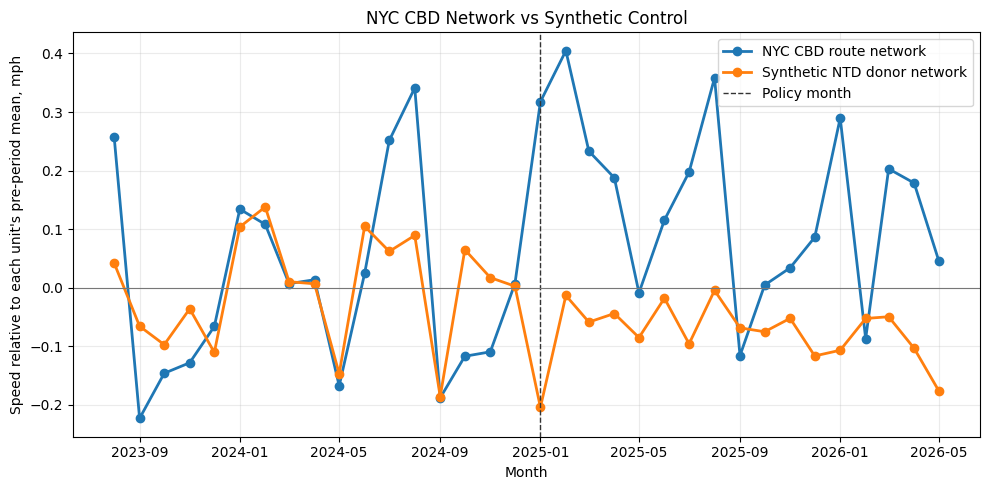

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(result["month"], result["treated_centered_speed"], marker="o", linewidth=2, label="NYC CBD route network")
ax.plot(result["month"], result["synthetic_centered_speed"], marker="o", linewidth=2, label="Synthetic NTD donor network")
ax.axvline(POLICY_MONTH, color="#333333", linestyle="--", linewidth=1, label="Policy month")
ax.axhline(0, color="#777777", linewidth=0.8)
ax.set_title("NYC CBD Network vs Synthetic Control")
ax.set_ylabel("Speed relative to each unit's pre-period mean, mph")
ax.set_xlabel("Month")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "nyc_cbd_ntd_synthetic_control_fit.png", dpi=220, bbox_inches="tight")
plt.show()

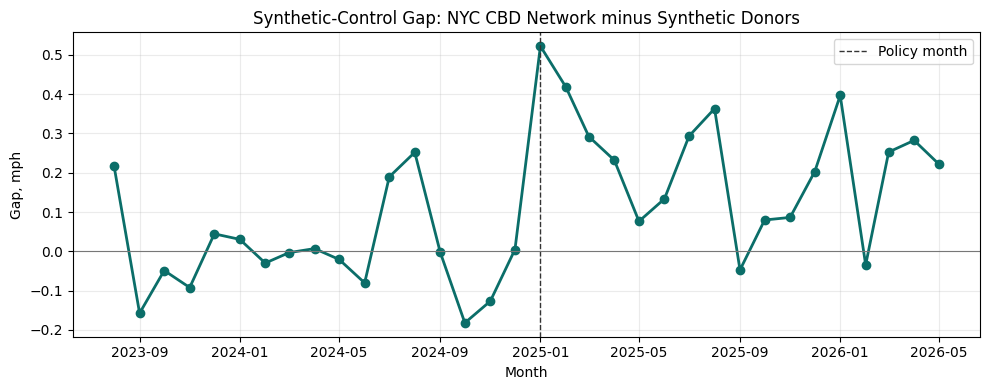

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(result["month"], result["gap_mph"], marker="o", linewidth=2, color="#0b6e69")
ax.axvline(POLICY_MONTH, color="#333333", linestyle="--", linewidth=1, label="Policy month")
ax.axhline(0, color="#777777", linewidth=0.8)
ax.set_title("Synthetic-Control Gap: NYC CBD Network minus Synthetic Donors")
ax.set_ylabel("Gap, mph")
ax.set_xlabel("Month")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "nyc_cbd_ntd_synthetic_control_gap.png", dpi=220, bbox_inches="tight")
plt.show()

## Step 7. Interpretation Guardrails

This design is most useful as a robustness exercise.

Strengths:

- donor pool is broad and built from a consistent national source;
- NYC-area agencies are excluded from the donor pool;
- weights are learned only from the pre-policy period;
- the treated unit matches the original GeoJSON treatment definition.

Limitations:

- NTD donor speeds are agency-level, not CBD-like route-subnetwork speeds;
- the treated NYC outcome is derived from route-level MTA bus speeds, while donor outcomes are VRM/VRH agency speeds;
- the pre-period has only 17 months, so overfitting remains a concern even with a limited donor pool;
- results should be read alongside the main NYC DiD and event-study diagnostics.

In [24]:
print("Saved outputs:")
for path in [
    PROCESSED / "ntd_monthly_bus_speeds.csv",
    TABLES / "ntd_synthetic_control_excluded_nyc_area_agencies.csv",
    TABLES / "ntd_synthetic_control_donor_pool.csv",
    TABLES / "nyc_cbd_ntd_synthetic_control_weights.csv",
    TABLES / "nyc_cbd_ntd_synthetic_control_monthly_results.csv",
    TABLES / "nyc_cbd_ntd_synthetic_control_summary.csv",
    FIGURES / "nyc_cbd_ntd_synthetic_control_fit.png",
    FIGURES / "nyc_cbd_ntd_synthetic_control_gap.png",
]:
    print(path.relative_to(ROOT))

Saved outputs:
data\processed\ntd_monthly_bus_speeds.csv
outputs\tables\ntd_synthetic_control_excluded_nyc_area_agencies.csv
outputs\tables\ntd_synthetic_control_donor_pool.csv
outputs\tables\nyc_cbd_ntd_synthetic_control_weights.csv
outputs\tables\nyc_cbd_ntd_synthetic_control_monthly_results.csv
outputs\tables\nyc_cbd_ntd_synthetic_control_summary.csv
outputs\figures\nyc_cbd_ntd_synthetic_control_fit.png
outputs\figures\nyc_cbd_ntd_synthetic_control_gap.png
